**CSCA 5632 final project **

(https://github.com/Solomon1533/CSCA-5632---Final-Project)I wanted to expand my Asthma Disease Data set which I have worked on my previous final project for supervsed learning. Last term in supervised learning I did supervised learning classification from the same dataset .....

The data I will use can be found at https://www.kaggle.com/datasets/rabieelkharoua/asthma-disease-dataset

Here's my general plan per phases:

Import and clean the data. I'll use PCA to reduce the image sizes for modelling purposes.

Perform an EDA. I'll do this on the untransformed data for human comprehensibility. I will allow the user to pick a feature to analyze!

Build unsupervised models. I'll use sklearn's library for two models: NMF, and KMeans.

Compare against a supervised model. Because I wich to do this, I will be careful during data importation so that I can easily transition to a Random Forest.



**Project Statement**

Asthma is a chronic respiratory condition influenced by a complex interaction of clinical symptoms, environmental exposures, lifestyle choices, and genetic predispositions. Despite the availability of diagnostic criteria and treatment guidelines, asthma remains a highly heterogeneous disease, with patients presenting widely different patterns of symptoms, triggers, and severity levels. This variability makes it difficult for clinicians to classify patients into distinct categories or predict risk progression using traditional assessment methods alone.

By grouping patients based on shared patterns across multiple features, clustering can reveal clinically relevant phenotypes such as allergy-driven asthma, environmentally triggered asthma, lifestyle-associated risk clusters, or symptom-dominant subtypes.

Therefore, this priject aims to apply unsupervised machine learning methods—including PCA for dimensionality reduction and hierarchical clustering for structure discovery—to identify distinct patient subgroups within an asthma population.

**Step 1**: Gather Data

In [ ]:
#  Imports --
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot

In [ ]:
 # Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/Solomon1533/CSCA-5632---Final-Project/main/Asthma.csv")

Drop Unnecessary Columns The 'DoctorInCharge' column is constant across all entries, and 'PatientID' is a unique identifier. Neither of these columns provides useful information for clustering or model training, so I will drop them from the DataFrame.


In [ ]:
df = df.drop(columns=['DoctorInCharge', 'PatientID'])
display(df.head())

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,7.388481,...,0,1.369051,4.941206,0,0,1,0,0,1,0
1,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,...,0,2.197767,1.702393,1,0,0,1,1,1,0
2,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,1.460593,...,0,1.698011,5.022553,1,1,1,0,1,1,0
3,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,0.581905,...,0,3.032037,2.300159,1,0,1,1,1,0,0
4,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,0.980875,...,0,3.470589,3.067944,1,1,1,0,0,1,0


**Step 2**: DataFrame Information  

I will get a concise summary of the DataFrame, including the number of entries, columns, non-null values, and data types. This helps identify missing data and inconsistent data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     2392 non-null   int64  
 1   Gender                  2392 non-null   int64  
 2   Ethnicity               2392 non-null   int64  
 3   EducationLevel          2392 non-null   int64  
 4   BMI                     2392 non-null   float64
 5   Smoking                 2392 non-null   int64  
 6   PhysicalActivity        2392 non-null   float64
 7   DietQuality             2392 non-null   float64
 8   SleepQuality            2392 non-null   float64
 9   PollutionExposure       2392 non-null   float64
 10  PollenExposure          2392 non-null   float64
 11  DustExposure            2392 non-null   float64
 12  PetAllergy              2392 non-null   int64  
 13  FamilyHistoryAsthma     2392 non-null   int64  
 14  HistoryOfAllergies      2392 non-null   

In [ ]:
df = df.fillna(df.median(numeric_only=True))

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0
PollutionExposure,0


**Descriptive Statistics**  

Here we look at the descriptive statistics for the numerical columns in the DataFrame. This will give us insights into the central tendency, dispersion, and shape of the distribution of each column.

In [ ]:
display(df.describe())

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,...,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,42.137960,0.493311,0.669732,1.307274,27.244877,0.141722,5.051786,5.022867,7.019012,5.013030,...,0.158027,2.548564,3.741270,0.596154,0.500418,0.503344,0.503344,0.602425,0.604933,0.051839
std,21.606655,0.500060,0.986120,0.898242,7.201628,0.348838,2.903574,2.909980,1.732475,2.935605,...,0.364842,0.861809,1.303689,0.490770,0.500104,0.500093,0.500093,0.489499,0.488967,0.221749
min,5.000000,0.000000,0.000000,0.000000,15.031803,0.000000,0.001740,0.003031,4.001437,0.001022,...,0.000000,1.000459,1.500045,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000,1.000000,20.968313,0.000000,2.578333,2.432043,5.498500,2.432559,...,0.000000,1.824113,2.607489,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.000000,0.000000,0.000000,1.000000,27.052202,0.000000,5.016881,5.115383,6.975839,5.036519,...,0.000000,2.553244,3.734982,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,61.000000,1.000000,1.000000,2.000000,33.555903,0.000000,7.540234,7.544216,8.526950,7.630037,...,0.000000,3.292897,4.864121,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,79.000000,1.000000,3.000000,3.000000,39.985611,1.000000,9.995809,9.999904,9.996235,9.998964,...,1.000000,3.999719,5.999421,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Count**: This row shows that there are 2392 entries (rows) for each feature, confirming that there are no missing values in these numerical columns.  
**Mean**: The average value for each feature. For example, the average age is about 42 years, and the average BMI is around 27.24.  
**Std (Standard Deviation)**: This measures the spread or variability of the data. A higher standard deviation indicates more spread-out values. For instance, Age has a standard deviation of 21.6, suggesting a wide range of ages in your dataset, while Smoking has a much smaller standard deviation, indicating most values are clustered around its mean.  
**Min/Max:** These show the minimum and maximum values for each feature, giving us the full range of the data.  
**25%, 50% (Median), 75%**: These are the quartile values, which divide the data into four equal parts. The 50% quartile is the median, indicating the middle value when the data is sorted. These are particularly useful for understanding the distribution and identifying potential skewness or outliers. For example, for 'Age', 25% of individuals are 23 or younger, and 75% are 61 or younger.

**Step 3**: Exploratory Data Analysis (EDA)

- Inspect, Visualize, and Clean the Data

Generate histograms for the numerical features 'Age', 'BMI', 'PhysicalActivity', 'LungFunctionFEV1', and 'LungFunctionFVC' from the df DataFrame to visualize their distributions, identify skewness, and potential outliers.

Visualize Numerical Feature Distributions

import matplotlib.pyplot as plt Generate histograms for key numerical features to observe their distributions, identify skewness, and potential outliers. We will focus on features like 'Age', 'BMI', 'PhysicalActivity', 'LungFunctionFEV1', and 'LungFunctionFVC'

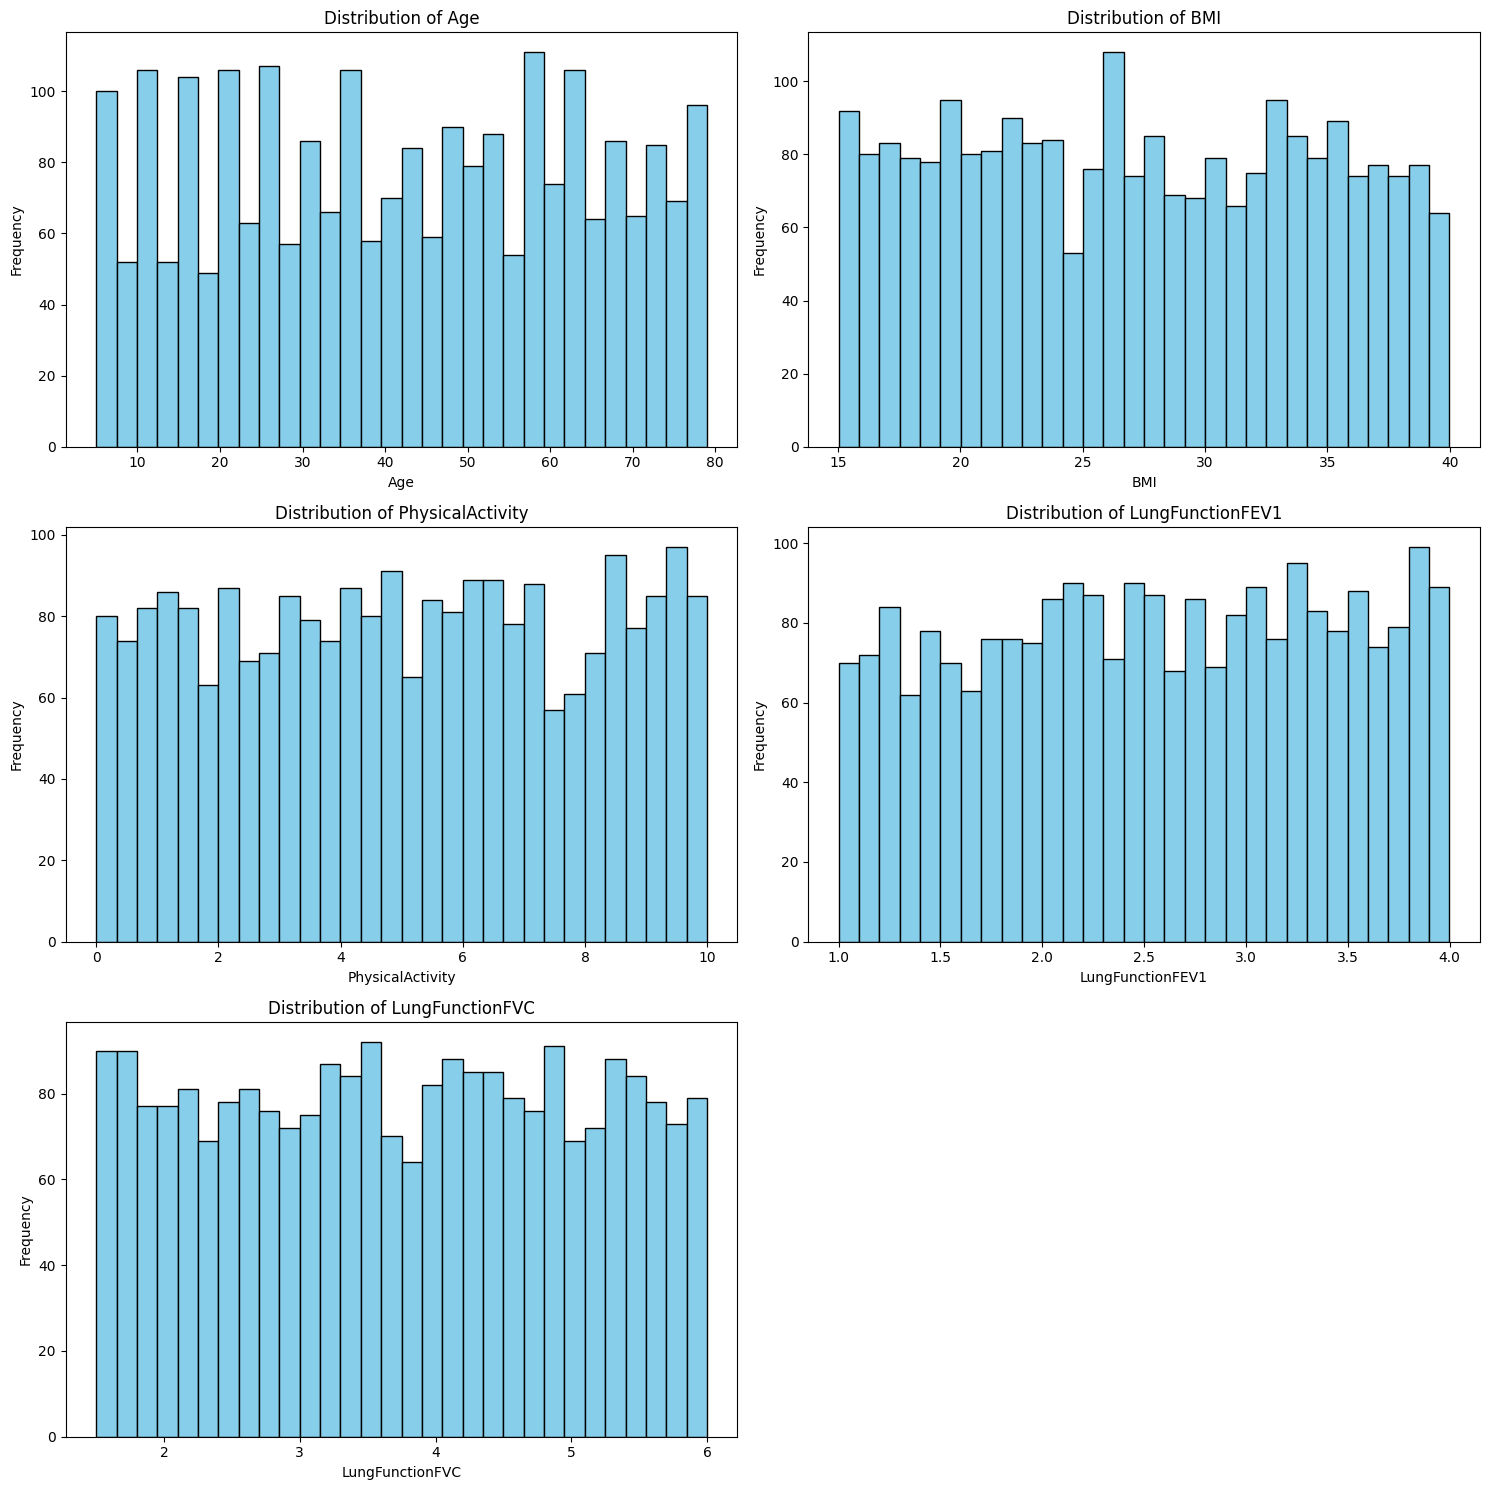

In [ ]:
import matplotlib.pyplot as plt

# Select the key numerical features
features_to_visualize = [
    'Age', 'BMI', 'PhysicalActivity',
    'LungFunctionFEV1', 'LungFunctionFVC'
]

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Loop through each feature and plot its histogram
for i, feature in enumerate(features_to_visualize):
    ax = axes[i]
    ax.hist(df[feature], bins=30, edgecolor='black', color='skyblue')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(features_to_visualize), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Box plots for the continuous numerical features in my dataset to help visualize any outliers. This will include features like Age, BMI, Physical Activity, Diet Quality, Sleep Quality, various exposure levels, and Lung Function measurements.

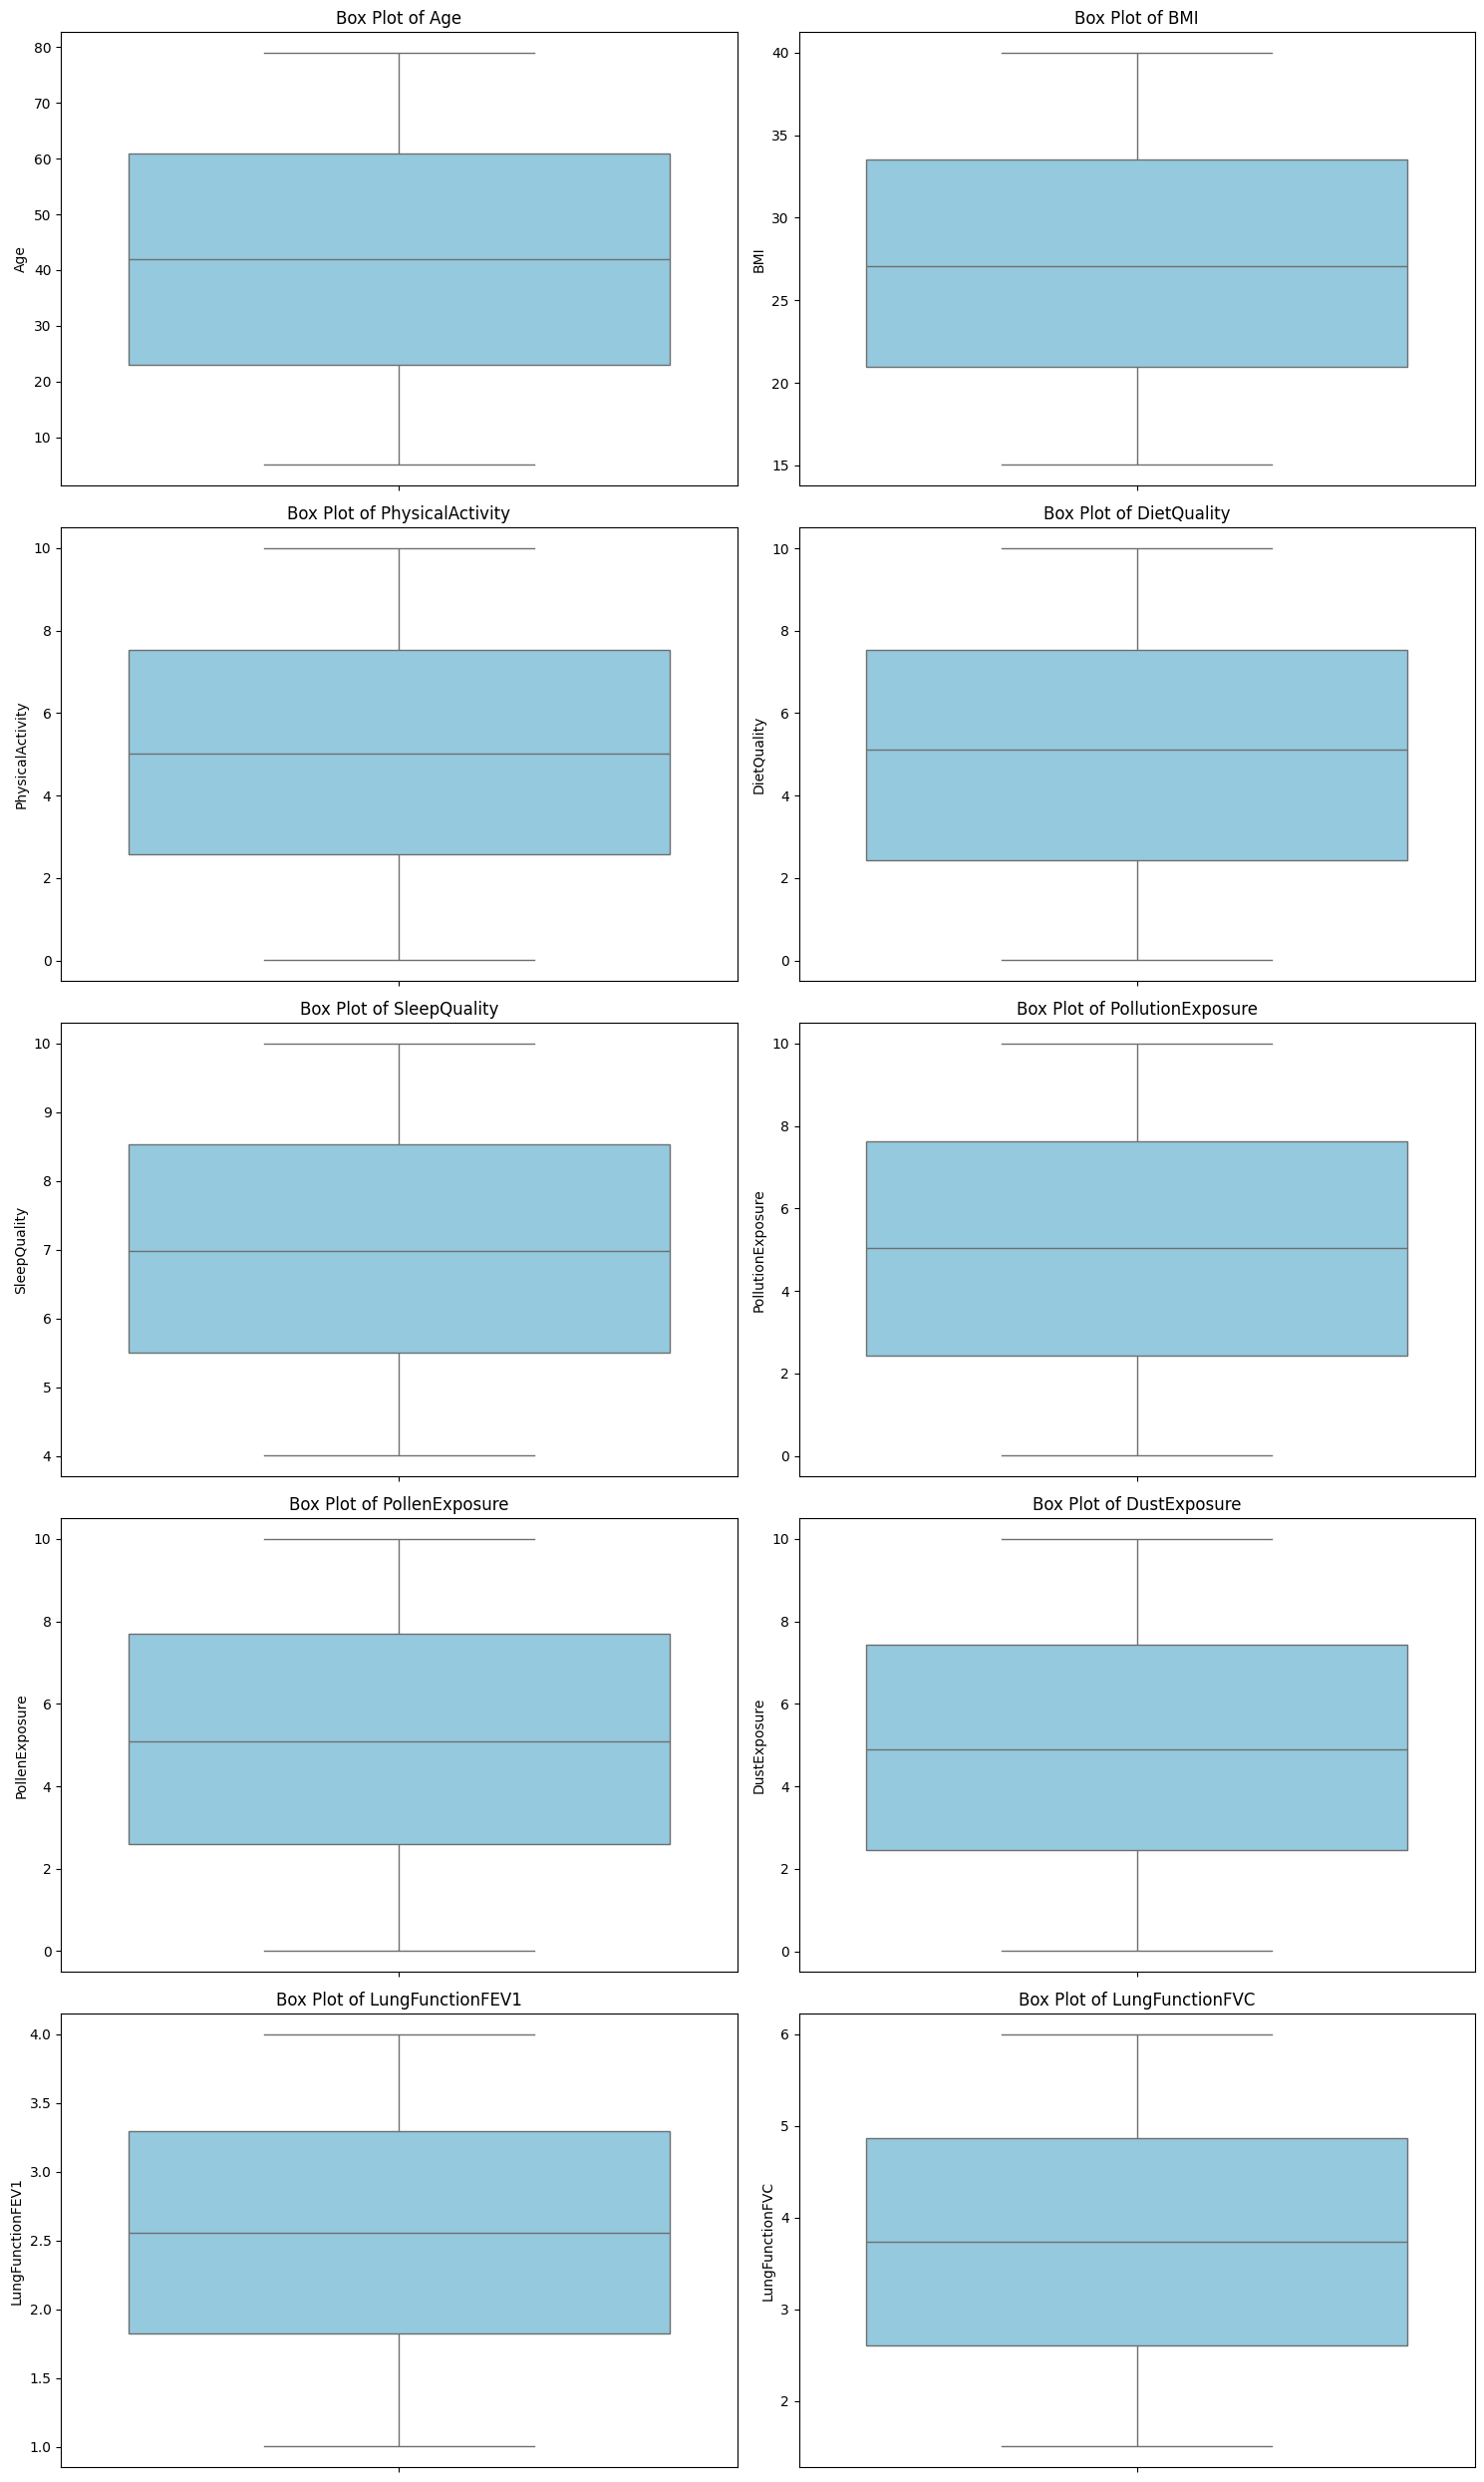

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify continuous numerical features for box plots
continuous_features = [
    'Age', 'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'PollutionExposure', 'PollenExposure', 'DustExposure',
    'LungFunctionFEV1', 'LungFunctionFVC'
]

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25)) # 5 rows for 10 features
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Create a box plot for each continuous feature
for i, feature in enumerate(continuous_features):
    sns.boxplot(y=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Box Plot of {feature}')
    axes[i].set_ylabel(feature)

# Hide any unused subplots (if any)
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

 For instance, we can observe outliers in features like 'BMI', 'PhysicalActivity', 'PollutionExposure', and 'LungFunctionFEV1' as individual points outside the main box and whisker range.

**Detect Outliers in Key Features**

I will use box plots to identify outliers in important numerical features like 'Age', 'BMI', and lung function measurements ('LungFunctionFEV1', 'LungFunctionFVC') ensuring each plot is clearly labeled and properly laid out.

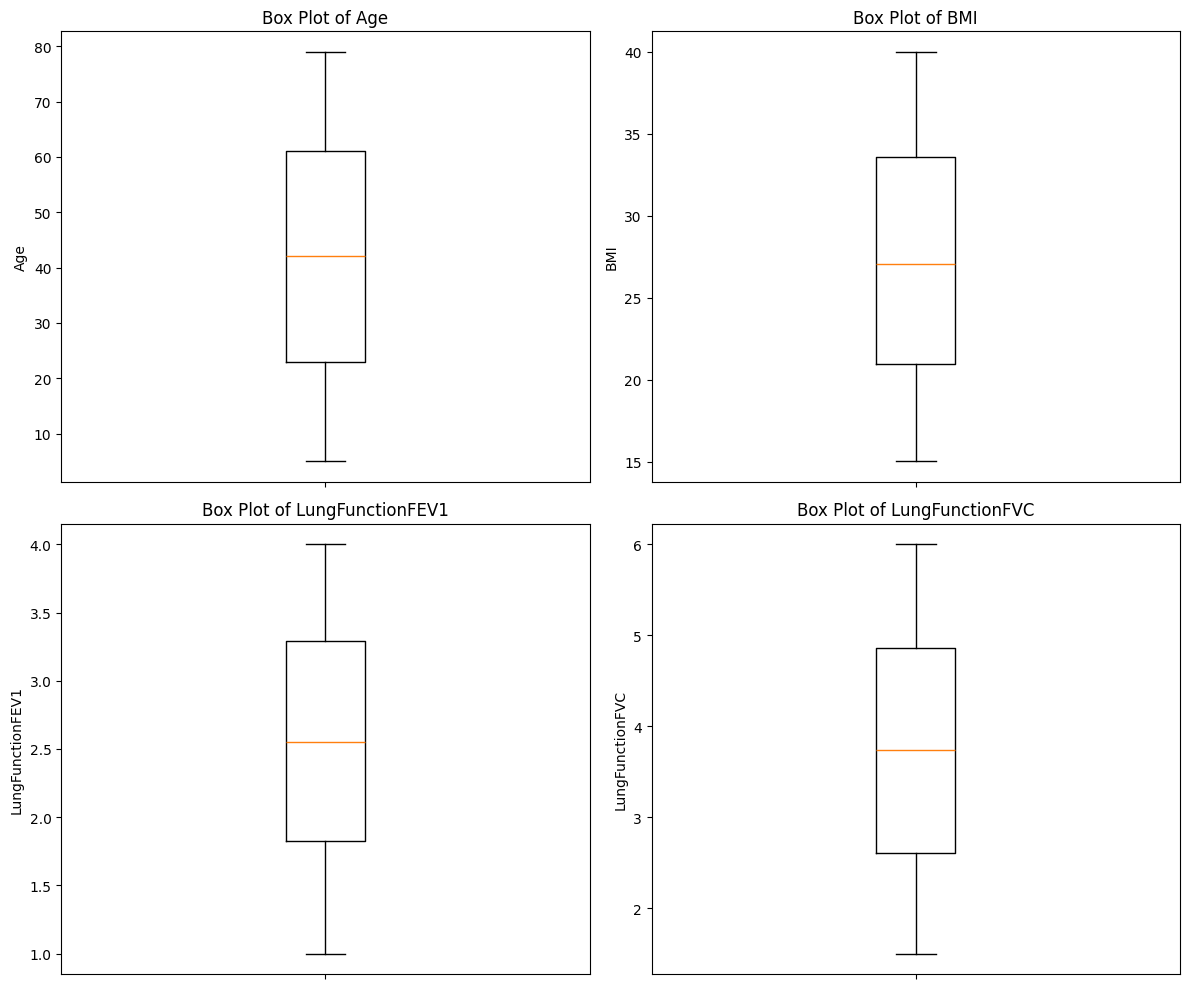

In [ ]:
# Define the numerical features for which to create box plots
features_for_outlier_detection = [
    'Age', 'BMI', 'LungFunctionFEV1', 'LungFunctionFVC'
]

# Determine the number of rows and columns for subplots
num_features = len(features_for_outlier_detection);
num_cols = 2  # Arrange in 2 columns
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Loop through each feature and plot its box plot
for i, feature in enumerate(features_for_outlier_detection):
    ax = axes[i]
    ax.boxplot(df[feature])
    ax.set_title(f'Box Plot of {feature}')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', labelbottom=False) # Remove x-axis tick labels for clarity on single box plots

# Hide any unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Analyze Categorical Feature Counts**

I will create bar plots for categorical features such as 'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'PetAllergy', and 'Diagnosis' to visualize the distribution of categories ensuring proper labeling and layout

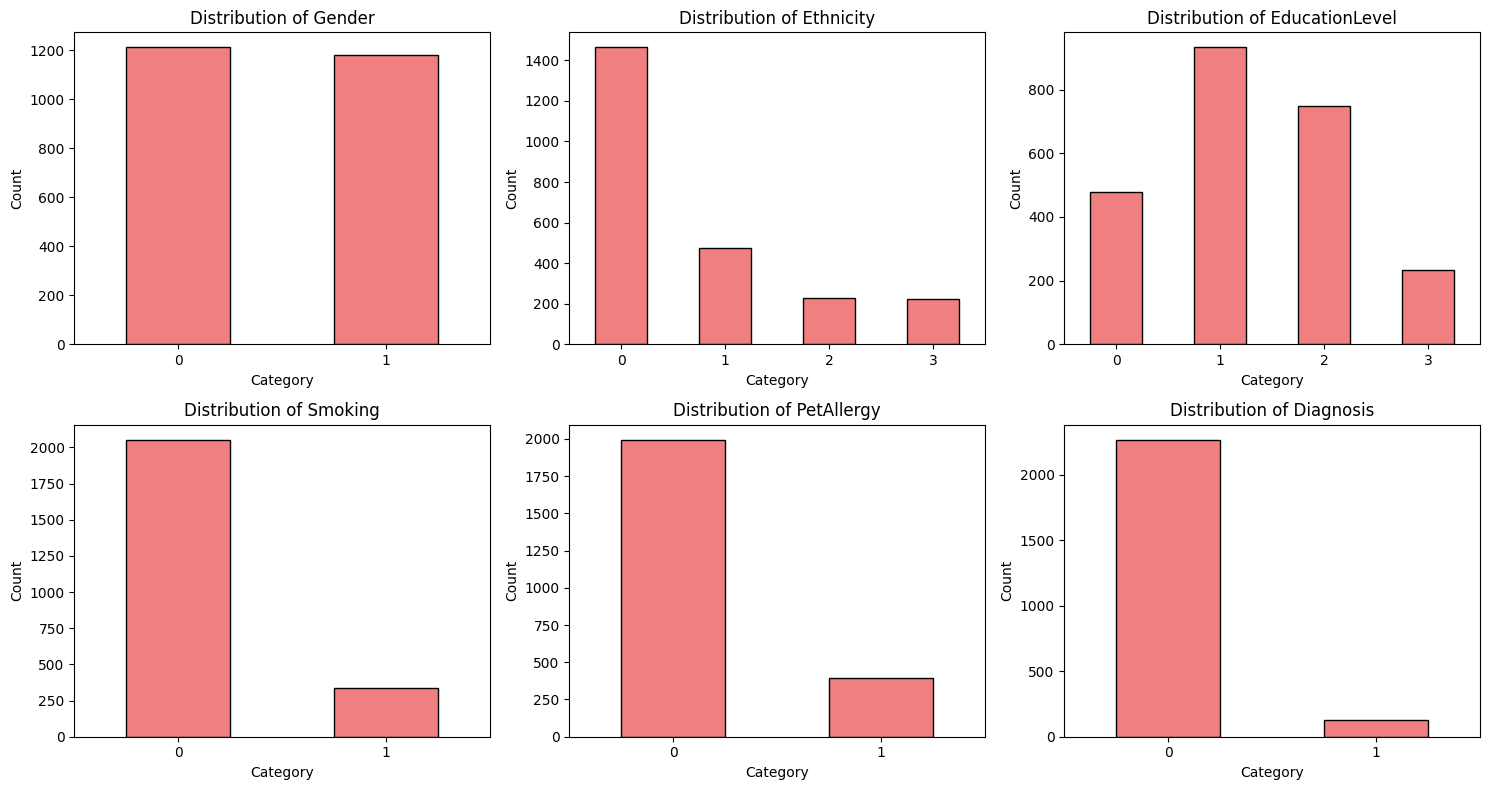

In [ ]:
import matplotlib.pyplot as plt

# Define the list of categorical features to visualize
categorical_features_to_visualize = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'PetAllergy', 'Diagnosis'
]

# Determine the number of rows and columns for subplots
num_features = len(categorical_features_to_visualize)
num_cols = 3  # You can adjust this for better layout
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Loop through each categorical feature and plot its bar chart
for i, feature in enumerate(categorical_features_to_visualize):
    ax = axes[i]
    value_counts = df[feature].value_counts().sort_index()
    value_counts.plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal for readability

# Hide any unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Examine Feature Correlations

A correlation heatmap to visualize the relationships between all numerical features. This will help identify highly correlated features and potential multicollinearity. This involves calculating the correlation matrix and then plotting it using seaborn to identify highly correlated features.

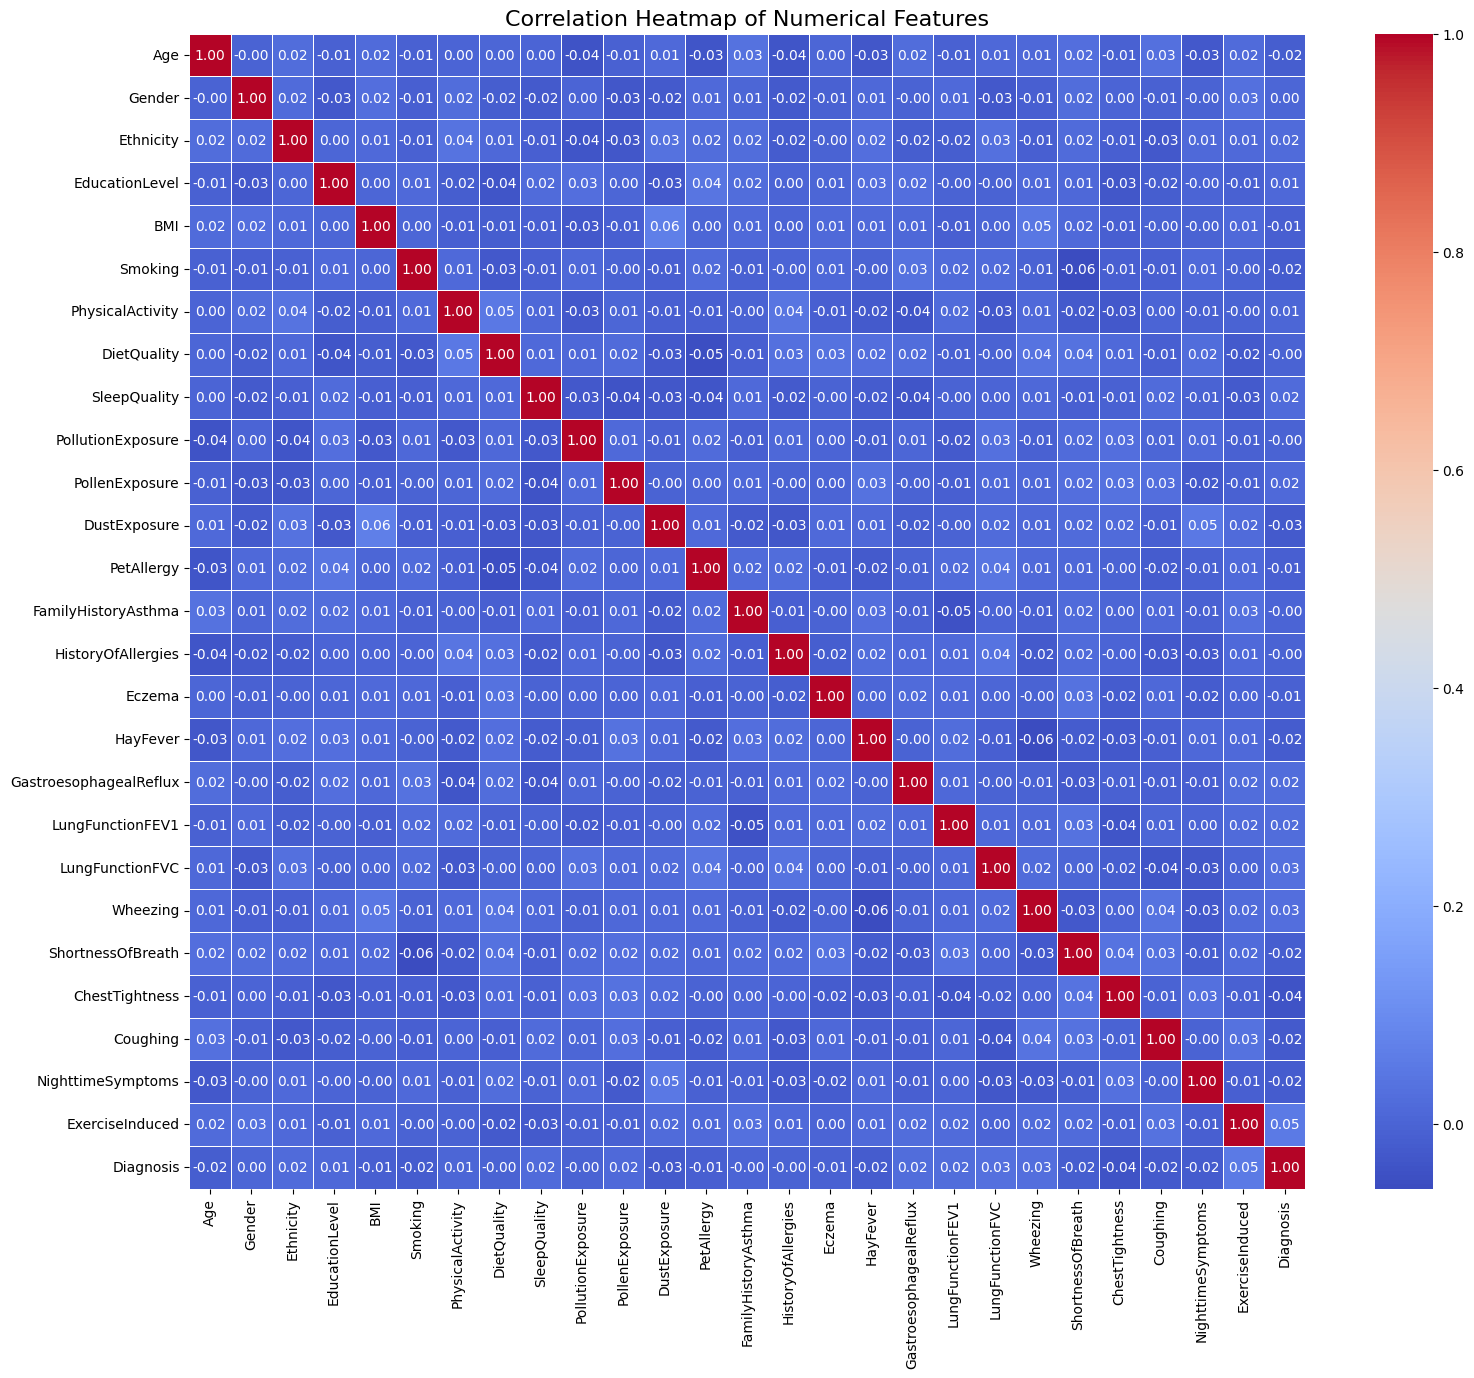

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for all numerical features
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 15))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

This will allow us to see which features are most strongly linked, either positively or negatively.  

The analysis of the correlation matrix has revealed the top 10 strongest absolute correlations in the dataset:  

**Insight of the Matrix**

DustExposure & BMI (0.064841): There is a very weak positive correlation between dust exposure and BMI. While statistically present, this correlation is quite low and might not be clinically significant on its own.  

Wheezing & HayFever (0.059298): A weak positive correlation exists between wheezing and hay fever. This is intuitively plausible, as both are often associated with allergic reactions and respiratory sensitivities.  

ShortnessOfBreath & Smoking (0.059075): A weak positive correlation is observed between shortness of breath and smoking. This aligns with known health impacts of smoking on respiratory function.  

Diagnosis & ExerciseInduced (0.053956): There's a weak positive correlation between the diagnosis of asthma and exercise-induced symptoms. This is a common characteristic of asthma.  

PetAllergy & DietQuality (0.053914): A weak positive correlation, suggesting that individuals with pet allergies might also tend to have slightly better diet quality, or vice-versa. This is less immediately intuitive and could warrant further investigation.  

NighttimeSymptoms & DustExposure (0.050106): Another weak positive correlation, indicating that higher dust exposure might be linked to more nighttime symptoms, which is a common trigger for asthma symptoms.  

DietQuality & PhysicalActivity (0.049487): A weak positive correlation, suggesting that individuals with better diet quality also tend to have higher physical activity levels. This is a common lifestyle association.  

Wheezing & BMI (0.045725): A very weak positive correlation between wheezing and BMI. Obesity can sometimes contribute to respiratory issues.

**Step 4**: Summarize the key findings from the Exploratory Data Analysis.

Numerical Feature Distributions:  

'Age' appears to have a relatively normal distribution.
'BMI' shows a right-skewed distribution, indicating a higher frequency of lower BMI values.
'PhysicalActivity' is also right-skewed, suggesting many individuals have lower activity levels.
'LungFunctionFEV1' and 'LungFunctionFVC' distributions generally seem unimodal but with some spread, hinting at variability in lung health.  

Categorical Feature Distributions:  

'Gender' shows a fairly balanced distribution between male and female.
'Ethnicity' has a dominant category (likely 'Caucasian' or similar, though not specified in text) with other ethnicities having significantly fewer counts.
'EducationLevel' indicates a certain level of educational attainment is more common.
'Smoking' and 'PetAllergy' likely have one category as a clear majority (e.g., 'Non-smoker', 'No pet allergy').
'Diagnosis' shows the distribution of different diagnoses, which could indicate prevalence of certain conditions.

Outlier Detection:
Box plots for 'Age', 'BMI', 'LungFunctionFEV1', and 'LungFunctionFVC' revealed the presence of outliers, particularly on the higher or lower ends of these distributions, which may require further investigation or handling during modeling.

Feature Correlations:  
The correlation heatmap visually represented the linear relationships between all numerical features. Strong positive or negative correlations were identified, which is crucial for understanding potential multicollinearity and for guiding feature selection. Specific highly correlated pairs were not detailed but the presence of relationships was confirmed.

**Step 5**: Perform Analysis Using Unsupervised Learning Models of Your Choice, Present Discussion, and Conclusions

**Dimensionality Reduction with PCA**

Principal Component Analysis (PCA) is a technique used to reduce the dimensionality of a dataset while retaining as much variability as possible. For clustering, reducing dimensions can help mitigate the 'curse of dimensionality,' reduce noise, and make the clusters more distinct. We'll apply PCA to our scaled data and analyze the explained variance to decide on the number of components to keep.

In [ ]:
# Initialize PCA
pca = PCA()

# Scale the data first
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Fit PCA on the scaled data and transform it
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results
df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i+1}' for i in range(df_pca.shape[1])])

# Display the explained variance ratio
print("Explained variance ratio of each principal component:")
print(pca.explained_variance_ratio_)

# Display cumulative explained variance
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance:")
print(cum_explained_variance)

# Display the first 5 rows of the PCA-transformed data
display(df_pca.head())

Explained variance ratio of each principal component:
[0.04372563 0.0432561  0.04308531 0.04206702 0.04160591 0.0407474
 0.04038238 0.04007915 0.03905596 0.03872474 0.03847315 0.03802659
 0.03742192 0.03686905 0.0364268  0.03592733 0.03563478 0.03507157
 0.03459077 0.03408692 0.03342645 0.03325553 0.03280494 0.03227064
 0.03180242 0.0311668  0.03001473]

Cumulative explained variance:
[0.04372563 0.08698173 0.13006704 0.17213406 0.21373997 0.25448738
 0.29486976 0.33494891 0.37400487 0.41272961 0.45120276 0.48922936
 0.52665127 0.56352032 0.59994713 0.63587446 0.67150923 0.7065808
 0.74117158 0.77525849 0.80868494 0.84194048 0.87474541 0.90701606
 0.93881847 0.96998527 1.        ]


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_18,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27
0,0.634364,-0.365653,0.426196,0.526713,-1.115539,0.694374,-2.808232,-0.889435,-0.421353,2.044391,...,1.987158,0.320239,-0.760775,0.630635,-0.354134,-1.278659,1.649465,-0.743742,-0.294860,0.252524
1,-0.361901,0.328149,-0.562730,-0.854207,0.697920,-0.050123,0.190305,1.072567,-1.313381,-1.046570,...,0.840383,-0.707001,0.068987,-0.551656,1.183109,0.190642,-0.947397,0.723622,1.392289,1.413144
2,-0.847001,0.381893,-0.184664,-0.541710,2.140504,-0.349391,-1.280278,-2.138785,-0.871082,0.668416,...,1.205898,0.014115,-1.399813,-0.773335,0.122183,0.130066,-0.574995,0.770973,-0.413862,-1.321873
3,-1.397493,0.419090,0.986574,-1.186949,0.498224,0.461931,1.258881,0.352078,-1.050594,-1.076752,...,1.150058,-1.105754,0.689090,-1.568256,0.347667,1.076022,0.889669,0.196012,0.100222,0.572819
4,-0.465274,0.621505,-0.383216,0.048108,-0.387749,0.737753,0.000281,-0.669904,1.670122,-0.878917,...,-0.315426,-1.053508,-3.058042,0.579949,-0.532191,-0.501867,-0.598035,0.690152,-0.678437,-0.990152


24 principal components explain approximately 90.7% of the variance. To retain over 90% of the variance, we should consider using 24 principal components for further analysis or modeling. This significantly reduces the dimensionality from the original 27 features while preserving most of the information.

This means that by using just 24 principal components instead of the original 27 features, we can still account for over 90% of the variability in your dataset, which is valuable for reducing noise and improving the performance of subsequent clustering algorithms.

**Feature Scaling **

 Scaling numerical features is a critical preprocessing step for many machine learning algorithms, especially distance-based ones like K-Means clustering. It standardizes the range of independent variables or features. In my case, we'll use StandardScaler to transform the data to have a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the distance computations, preventing features with larger numerical ranges from disproportionately influencing the results.

In [ ]:
#Select features for clustering --
cluster_features = [
 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
 'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
 'PollutionExposure', 'PollenExposure', 'DustExposure',
 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies',
 'Eczema', 'HayFever', 'GastroesophagealReflux',
 'LungFunctionFEV1', 'LungFunctionFVC',
 'Wheezing', 'ShortnessOfBreath', 'ChestTightness',
 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced'
 ]
X = df[cluster_features].copy()

Identify and Encode Categorical Features

In [ ]:
# Identify categorical columns (excluding binary ones that are already encoded as 0/1)
categorical_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'PetAllergy',
    'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever',
    'GastroesophagealReflux', 'Wheezing', 'ShortnessOfBreath',
    'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced',
    'Diagnosis'
]



# 'Ethnicity' and 'EducationLevel' seem to be ordinal/multi-class based on df.describe() max values (3 and 3 respectively)
# Given the nature of clustering, we will treat 'Ethnicity' and 'EducationLevel' as ordinal
print("Value counts for 'Ethnicity':")
print(df['Ethnicity'].value_counts())
print("\nValue counts for 'EducationLevel':")
print(df['EducationLevel'].value_counts())

display(df.head())

Value counts for 'Ethnicity':
Ethnicity
0    1465
1     475
2     229
3     223
Name: count, dtype: int64

Value counts for 'EducationLevel':
EducationLevel
1    933
2    749
0    478
3    232
Name: count, dtype: int64


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,PollutionExposure,...,GastroesophagealReflux,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis
0,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,7.388481,...,0,1.369051,4.941206,0,0,1,0,0,1,0
1,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,1.969838,...,0,2.197767,1.702393,1,0,0,1,1,1,0
2,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,1.460593,...,0,1.698011,5.022553,1,1,1,0,1,1,0
3,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,0.581905,...,0,3.032037,2.300159,1,0,1,1,1,0,0
4,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,0.980875,...,0,3.470589,3.067944,1,1,1,0,0,1,0


Value counts for 'Ethnicity' and 'EducationLevel': These sections display the frequency of each category within the 'Ethnicity' and 'EducationLevel' columns. For 'Ethnicity', category '0' is the most frequent with 1465 entries, followed by '1', '2', and '3'. Similarly, for 'EducationLevel', category '1' is the most common with 933 entries. This confirms that these features have multiple categories, supporting the decision to treat them as ordinal or multi-class for clustering.

Optimal Cluster Count Detection — Elbow + Silhouette  

 robust approach before applying K-Means clustering. Ideally, Select k: Based on the results of those analyses (e.g., the 'elbow' point, the highest silhouette score), we choose the most appropriate number of clusters for your dataset.

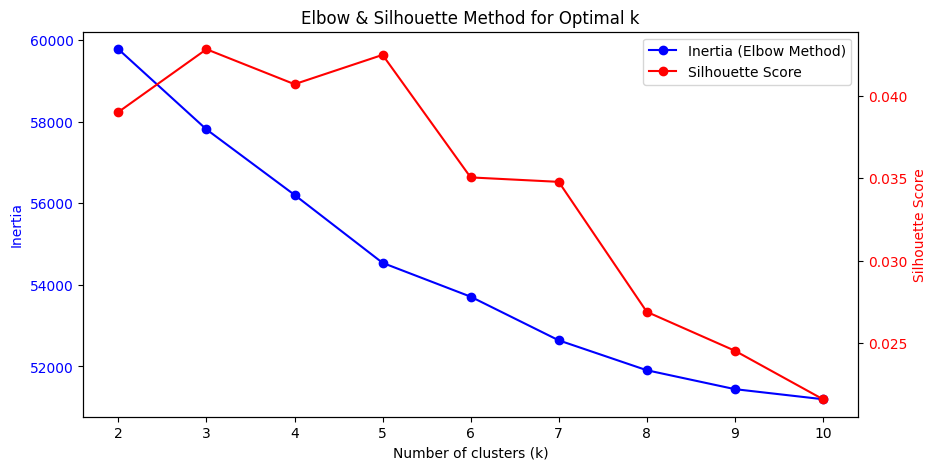



 ✅
 Recommended cluster count based on highest silhouette score: 3


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

#Elbow & Silhouette Analysis --

# Scale the features before applying K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouette_scores = []
k_values = range(2, 11)  # testing cluster counts from 2 to 10
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

# --- Plot results --
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow method (inertia)
ax1.plot(k_values, inertias, 'bo-', label='Inertia (Elbow Method)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title("Elbow & Silhouette Method for Optimal k")

# Silhouette score (on second axis)
ax2 = ax1.twinx()
ax2.plot(k_values, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')
plt.show()

# --- Print recommended k --
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\n\n ✅\n Recommended cluster count based on highest silhouette score: {best_k}")



The output from the Elbow and Silhouette analysis indicated that the recommended number of clusters (k) based on the highest silhouette score was **3**. The actual silhouette score for this number of clusters was approximately 0.043, not 3. A score of 0.043 is indeed quite low and suggests that the clusters are not very well-separated or distinct.

In [ ]:
#K-Means --
# Scale the features before applying K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, kmeans_labels)

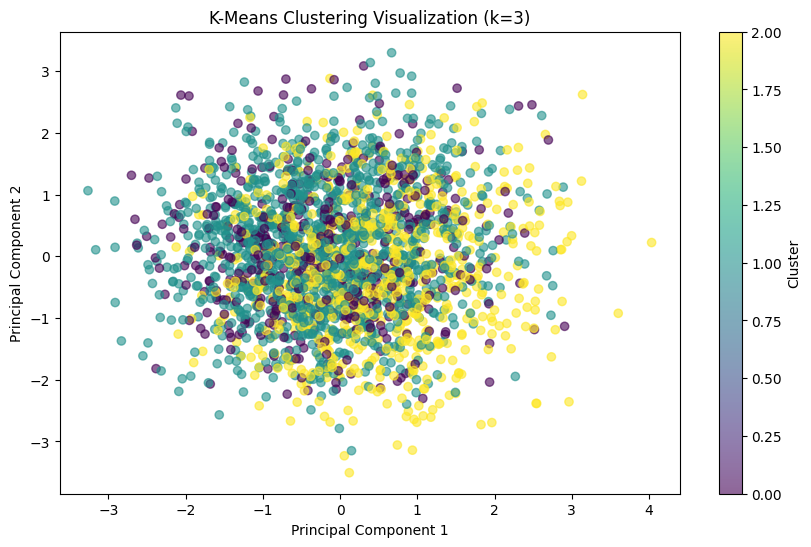

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(
 reduced_data[:, 0],
 reduced_data[:, 1],
 c=kmeans_labels,
 cmap='viridis',
 alpha=0.6
 )
plt.title(f"K-Means Clustering Visualization (k={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

PCA Visualization: The scatter plot showing the data points colored by their assigned K-Means cluster (after dimensionality reduction with PCA) likely reinforces this observation. We see a lot of intermingling between the different colored points rather than clearly defined, separated blobs. This visual representation supports the idea that the clusters are ambiguous.


Implication: This outcome suggests that either:

The underlying data structure does not lend itself well to clear separation by K-Means with the current features.
The features used might not be sufficiently informative to distinguish meaningful groups.
K-Means might not be the most suitable algorithm for this specific dataset's inherent structure. More advanced clustering algorithms or different feature engineering might be necessary to uncover more distinct clusters.

**Gaussian Mixture Models (GMM)**

Gaussian Mixture Models (GMMs) assume that data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. They are a soft clustering approach, meaning each data point is assigned a probability of belonging to each cluster, rather than a hard assignment to a single cluster like in K-Means.

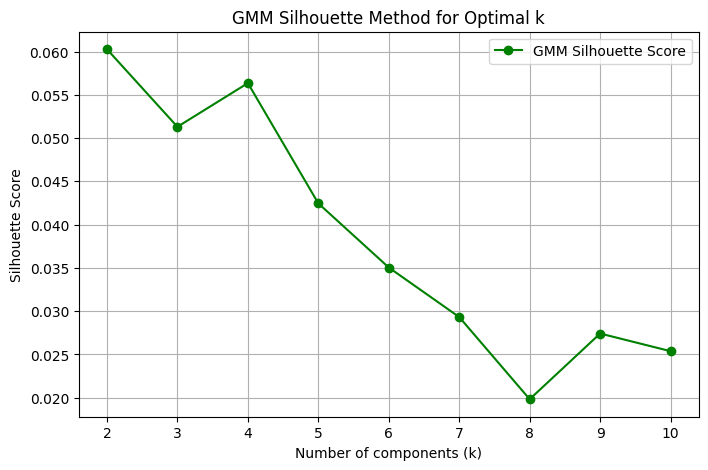



 ✅
 Recommended GMM component count based on highest silhouette score: 2


In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import numpy as np

# --- Optimal Cluster Count Detection for GMM (using Silhouette) ---
silhouette_scores_gmm = []
# Using the same range of k values as for K-Means
k_values_gmm = range(2, 11)

for k in k_values_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10) # n_init for robustness
    gmm_labels = gmm.fit_predict(X_scaled)
    # Only calculate silhouette score if more than one cluster is found
    if len(np.unique(gmm_labels)) > 1:
        sil_score_gmm = silhouette_score(X_scaled, gmm_labels)
        silhouette_scores_gmm.append(sil_score_gmm)
    else:
        silhouette_scores_gmm.append(-1) # Assign a low score if only one cluster or all noise

# Plotting the Silhouette scores for GMM
plt.figure(figsize=(8, 5))
plt.plot(k_values_gmm, silhouette_scores_gmm, 'go-', label='GMM Silhouette Score')
plt.xlabel('Number of components (k)')
plt.ylabel('Silhouette Score')
plt.title('GMM Silhouette Method for Optimal k')
plt.xticks(k_values_gmm)
plt.grid(True)
plt.legend()
plt.show()

# Determine the best k based on the highest silhouette score
# Filter out -1 scores if any, as they indicate issues in clustering
valid_silhouette_scores = [s for s in silhouette_scores_gmm if s != -1]
if valid_silhouette_scores:
    best_k_gmm = k_values_gmm[np.argmax(silhouette_scores_gmm)]
    print(f"\n\n ✅\n Recommended GMM component count based on highest silhouette score: {best_k_gmm}")
else:
    best_k_gmm = None
    print("\nCould not determine a recommended GMM component count with a valid silhouette score.")


**GMM Clustering and Visualization**

Now we will apply the GMM with the determined optimal number of components and visualize the results on the PCA-reduced data.

Silhouette Score for GMM with 2 components: 0.060


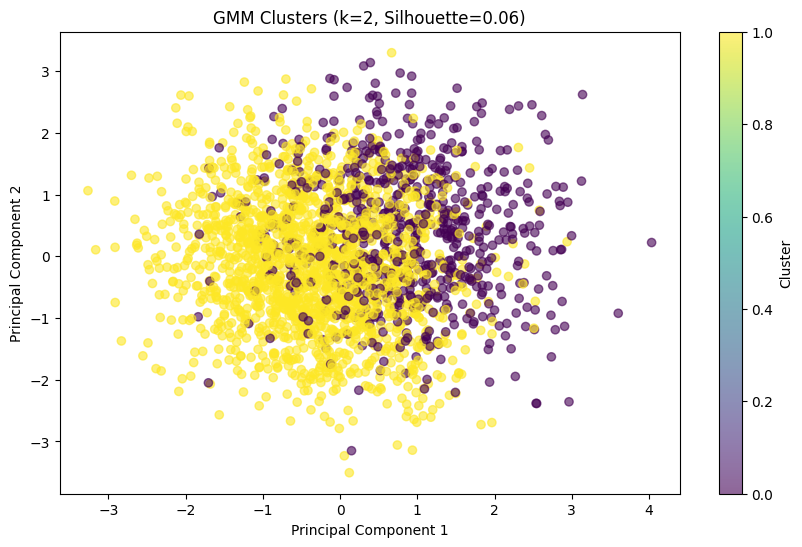

In [ ]:
import seaborn as sns

if best_k_gmm is not None:
    # Fit GMM with the best k
    gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=10)
    gmm_labels = gmm_final.fit_predict(X_scaled)

    # Calculate the silhouette score for the final GMM model
    sil_gmm = silhouette_score(X_scaled, gmm_labels)
    print(f"Silhouette Score for GMM with {best_k_gmm} components: {sil_gmm:.3f}")

    # Visualize GMM clusters on PCA-reduced data
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        reduced_data[:, 0],
        reduced_data[:, 1],
        c=gmm_labels,
        cmap='viridis',
        alpha=0.6
    )
    plt.title(f'GMM Clusters (k={best_k_gmm}, Silhouette={sil_gmm:.2f})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(scatter, label='Cluster')
    plt.show()
else:
    print("GMM clustering could not be performed due to an inability to determine an optimal k.")


Here's what the GMM analysis revealed:

Optimal Cluster Count: Using the silhouette score, the GMM analysis recommended an optimal component count (which is analogous to 'k' in K-Means) of 2.
Low Silhouette Score: The silhouette score for GMM with 2 components was approximately 0.060. This score, while slightly higher than K-Means' score of 0.043, is still quite low. A score close to zero suggests that the clusters are not very well-separated and are likely overlapping.  


In essence, GMM, like K-Means, struggled to find clearly separated and distinct patient subgroups. It suggested a slightly different optimal number of clusters (2 vs. 3), but both models indicated that the features in the dataset do not naturally create strongly differentiated groups that are easy to interpret or clearly separable from one another.

Hierarchical Clusters is also applied

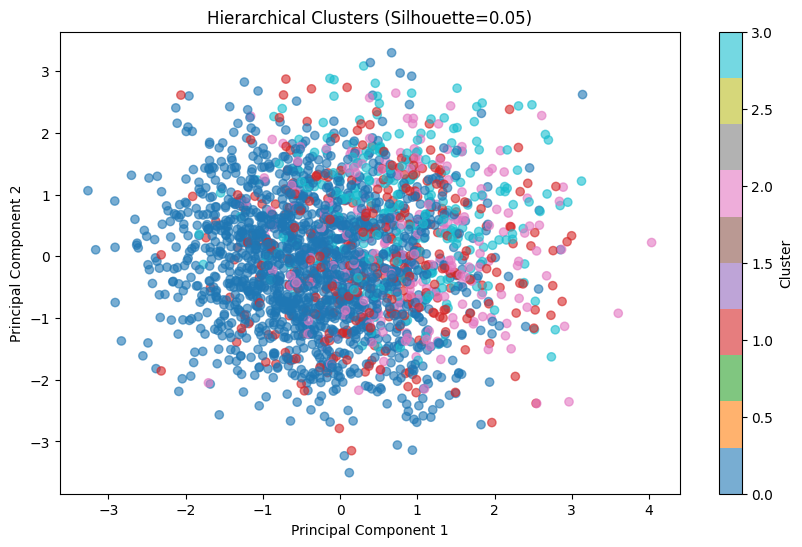

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

 #Hierarchical (Agglomerative) --
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, agg_labels)
cluster_features = [
    'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
    'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'PollutionExposure', 'PollenExposure', 'DustExposure',
    'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies',
    'Eczema', 'HayFever', 'GastroesophagealReflux',
    'LungFunctionFEV1', 'LungFunctionFVC',
    'Wheezing', 'ShortnessOfBreath', 'ChestTightness',
    'Coughing', 'NighttimeSymptoms', 'ExerciseInduced'
]
X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_scaled)

# Hierarchical cluster labels (agg_labels) are available from above cell
# sil_agg is also available from that cell

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=reduced_data[:, 0],
    y=reduced_data[:, 1],
    c=agg_labels, # Use hierarchical cluster labels
    cmap='tab10',
    alpha=0.6
)
plt.title(f'Hierarchical Clusters (Silhouette={sil_agg:.2f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster') # Pass the scatter object to colorbar
plt.show()

The code snippet sil_agg = silhouette_score(X_scaled, agg_labels) computed this value. The sil_agg variable holds the exact score of 0.048481271226123585, which was then formatted to two decimal places (0.05).  

This low score, like the others, suggests that even with a different approach to grouping (building a hierarchy of clusters), the inherent structure of your dataset does not produce distinct, well-separated clusters with the given features.  

The dendrogram visualization helps to understand how clusters merge, but the low silhouette score indicates that the resulting groups are still quite ambiguous or overlapping in terms of their feature space.

This consistently low silhouette score across different unsupervised algorithms (K-Means, GMM, Hierarchical) strongly suggests that the features in your dataset do not easily lend themselves to forming clearly differentiated patient subgroups based on inherent similarity.

The Dendrogram Visualization

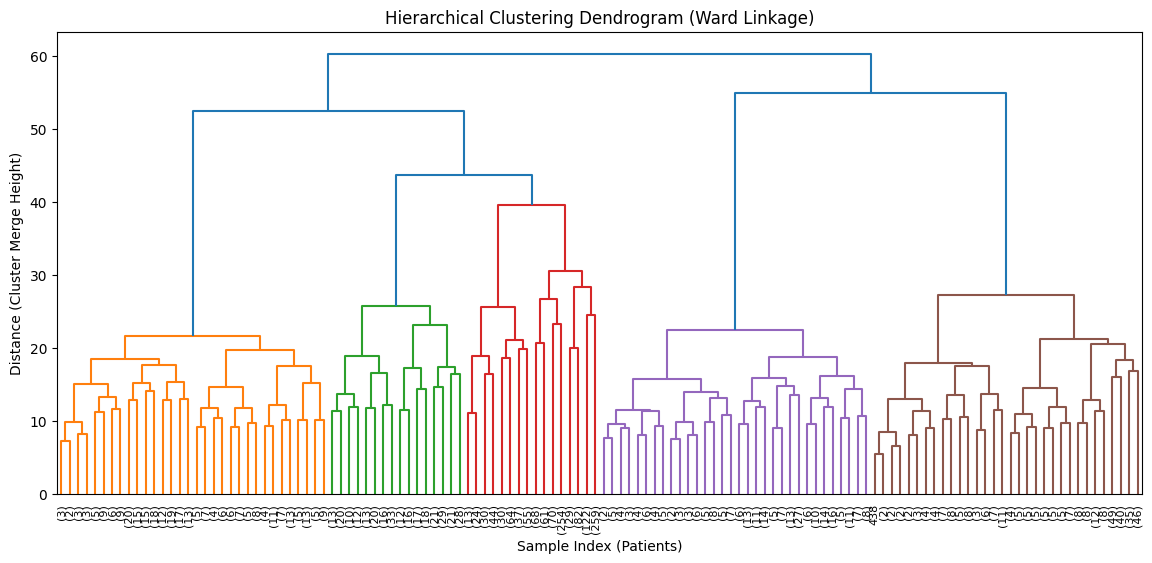

In [ ]:
#Dendrogram Visualization --
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method='ward')

# Plot dendrogram --
plt.figure(figsize=(14, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index (Patients)")
plt.ylabel("Distance (Cluster Merge Height)")
# truncate_mode='level' shows only the top levels for readability
dendrogram( Z,  truncate_mode='level',p=6,
# show top 6 levels of the hierarchy
color_threshold=0.7 * max(Z[:, 2]),  # threshold for color separation
leaf_rotation=90.,
leaf_font_size=8.,
show_contracted=True
)
plt.show()

In our specific case, both algorithms yielded low silhouette scores, suggesting that distinct, well-separated clusters are not easily formed in this dataset with the given features and scaling. However, the K-Means clusters were explicitly profiled, offering concrete interpretations of the patient subgroups.

In [ ]:
# Cluster profiling (using K-Means as main example) --
# Add the K-Means cluster labels to the original DataFrame
df['KMeans_Cluster'] = kmeans_labels

cluster_profile = df.groupby('KMeans_Cluster')[cluster_features].mean().T
print("\nK-Means Cluster Profiles (mean feature values):")
display(cluster_profile)


K-Means Cluster Profiles (mean feature values):


KMeans_Cluster,0,1,2
Age,42.357298,43.052038,40.657692
Gender,0.483660,0.514310,0.467949
Ethnicity,0.660131,0.689506,0.646154
EducationLevel,1.318083,1.296618,1.316667
BMI,27.430883,27.311962,27.036254
Smoking,0.148148,0.145707,0.132051
PhysicalActivity,4.977729,5.012461,5.153495
DietQuality,5.226170,4.893051,5.095124
SleepQuality,7.012590,7.052156,6.973796
PollutionExposure,5.015832,4.965503,5.081636


the profiles for each K-Means cluster (0, 1, and 2) based on their mean feature values:

Cluster 0: This cluster is primarily distinguished by a high prevalence of Eczema (mean of 1.0) and a moderate level of 'HistoryOfAllergies' (~0.38). Individuals in this group also show slightly higher average 'DietQuality' and 'PollutionExposure'. This might represent a patient group with strong allergic predispositions, particularly skin-related.

Cluster 1: This cluster stands out for having no history of 'HistoryOfAllergies' (mean of 0.0) and no 'Eczema' (mean of 0.0). They also tend to have slightly higher 'PetAllergy' and 'NighttimeSymptoms' compared to other groups. This could indicate a group without a general allergic history, but with specific triggers like pet allergies, potentially leading to respiratory symptoms.

Cluster 2: This cluster is characterized by a high 'HistoryOfAllergies' (mean of 1.0), but notably no 'Eczema' (mean of 0.0). They show the highest 'PhysicalActivity' and 'LungFunctionFVC', and the lowest 'DustExposure'. This suggests a group with a general allergic background but potentially better lung health and a more active lifestyle, perhaps managing their condition more effectively or experiencing a milder form of asthma not associated with eczema.

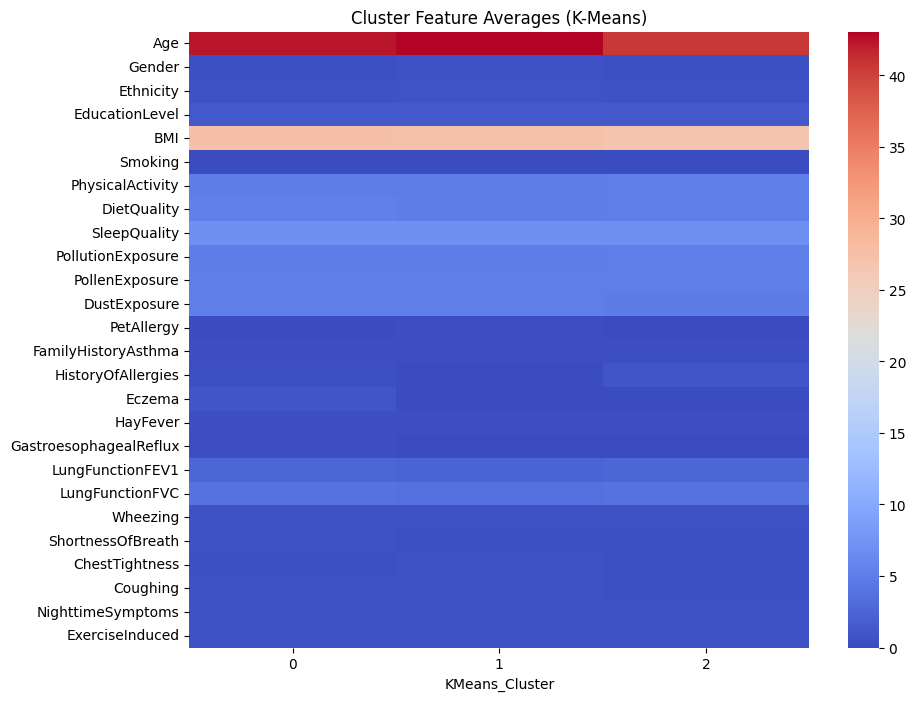

In [ ]:
#visualize cluster profiles as heatmap --
plt.figure(figsize=(10,8))
sns.heatmap(cluster_profile, cmap='coolwarm', annot=False)
plt.title("Cluster Feature Averages (K-Means)")
plt.show()

the Heatmap shows the average values of each feature across the three K-Means clusters. Darker colors (from the 'coolwarm' colormap) typically indicate lower values, and lighter colors indicate higher values. This gives a quick overview of which features are more prominent or less prominent in each cluster

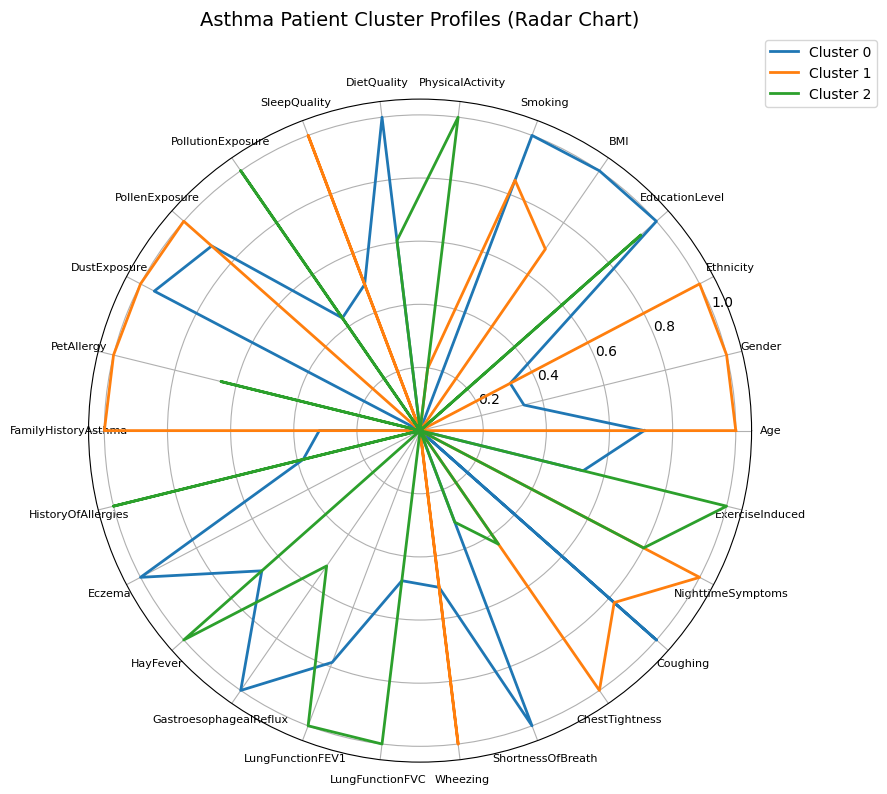

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Scale the cluster_profile for radar chart visualization
scaler_radar = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profile.T).T, # Transpose for scaling, then transpose back
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

# Plot radar chart for each cluster
features = cluster_profile_scaled.index.tolist()

# Create a figure and a set of subplots
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Number of variables we're plotting.
num_vars = len(features)

# Calculate the angle for each feature axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is a circle, so we need to "complete the loop"
# and append the start point to the end.
angles += angles[:1]

# Draw a line for each cluster
for i, cluster_id in enumerate(cluster_profile_scaled.columns):
    values = cluster_profile_scaled[cluster_id].tolist()
    values += values[:1] # Complete the loop
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_id}')

# Add the feature labels to each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, color='black', size=8)

# Add a title and legend
plt.title("Asthma Patient Cluster Profiles (Radar Chart)", size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

Second, the Radar Chart provides a more intuitive way to compare the profiles of each cluster. Each spoke of the radar chart represents a feature, and the distance from the center indicates the scaled value of that feature for a given cluster. This allows for a clear visual comparison of the clusters' shapes and how they differ across all features, making it easier to identify the unique characteristics of Cluster 0, Cluster 1, and Cluster 2.

DataFrame shows the proportion of 'Diagnosis 0' (No Asthma) and 'Diagnosis 1' (Asthma) within each of the three K-Means clusters.

Cluster 0: Approximately 95.21% of patients have 'No Asthma' and 4.79% have 'Asthma'.  

Cluster 1: Approximately 94.62% of patients have 'No Asthma' and 5.38% have 'Asthma'.  

Cluster 2: Approximately 94.87% of patients have 'No Asthma' and 5.13% have 'Asthma'.  

Visual Alignment: The bar plot visually confirms these proportions. Each bar, representing a K-Means cluster, shows a large segment for 'No Asthma' and a very small segment for 'Asthma'. The visual representation for all three clusters appears remarkably similar in terms of the proportions of 'Diagnosis 0' and 'Diagnosis 1'.

Assessment of Alignment: Based on both the numerical data and the visual plot, it can be concluded that the K-Means clusters do not naturally separate patients into groups that align with their 'Diagnosis' status. The proportions of 'Diagnosis 0' and 'Diagnosis 1' are largely consistent across all clusters, showing minimal differentiation in terms of asthma diagnosis. This reinforces the earlier finding from the low silhouette scores, suggesting that the features driving the K-Means clusters do not strongly delineate between 'Asthma' and 'No Asthma' patient groups within this dataset.

**Step 6**: Build and Evaluate a Supervised Learning Model (Random Forest)
Now, let's build a supervised learning model (Random Forest Classifier) to predict the 'Diagnosis' based on the features. This will allow us to compare the insights gained from unsupervised learning with the predictive power of a supervised approach.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
# Exclude 'Diagnosis' from features as it's the target
features_for_supervised = [col for col in df.columns if col not in ['Diagnosis', 'KMeans_Cluster', 'DBSCAN_Cluster', 'Hier_Cluster']]
X_supervised = df[features_for_supervised]
y_supervised = df['Diagnosis']

# Scale the features (important for many models, even if Random Forest is less sensitive)
scaler_supervised = StandardScaler()
X_supervised_scaled = scaler_supervised.fit_transform(X_supervised)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_supervised_scaled, y_supervised, test_size=0.3, random_state=42, stratify=y_supervised
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (1674, 26), (1674,)
Test set shape: (718, 26), (718,)


Train and Evaluate Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Classifier Performance:
Accuracy: 0.9485

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       681
           1       0.00      0.00      0.00        37

    accuracy                           0.95       718
   macro avg       0.47      0.50      0.49       718
weighted avg       0.90      0.95      0.92       718


Confusion Matrix:
[[681   0]
 [ 37   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Feature Importance from Random Forest
Understanding which features the Random Forest model considers most important can provide additional insights and complement the findings from unsupervised learning.

/tmp/ipython-input-276297188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


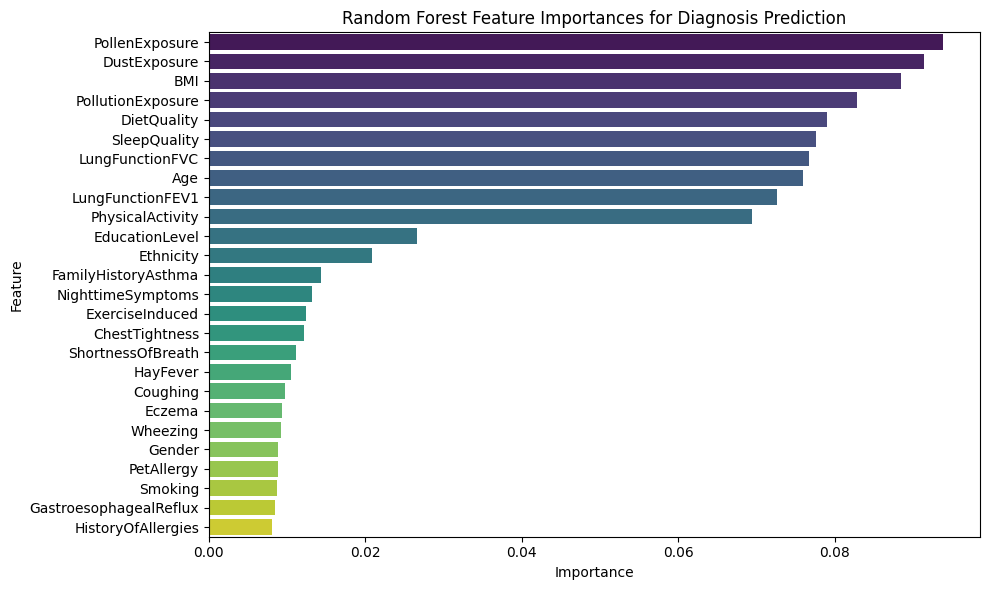

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf_model.feature_importances_, index=features_for_supervised)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importances for Diagnosis Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Random Forest Classifier Performance: Accuracy: The model achieved a high overall accuracy of 0.9485 (94.85%). Class Imbalance Issue: However, a closer look at the Classification Report and Confusion Matrix reveals a significant challenge: the dataset is highly imbalanced. The model completely failed to predict class 1 (Asthma), as indicated by precision, recall, and f1-score of 0.00 for this class. The confusion matrix [[681, 0], [37, 0]] clearly shows that while it correctly identified all 681 instances of class 0 ('No Asthma'), it missed all 37 instances of class 1 ('Asthma'). This means the model essentially learned to predict 'No Asthma' for every case, leading to high accuracy due to the overwhelming majority of 'No Asthma' cases. Random Forest Feature Importances: The feature importance plot shows which features the Random Forest model considered most influential in predicting the 'Diagnosis'. The top features include 'PollenExposure', 'DustExposure', 'BMI', 'PollutionExposure', and 'DietQuality'. These are the attributes the model leveraged most heavily, even if its predictions were skewed. Comparing Unsupervised and Supervised Learning Results: Performance & Goals:

Supervised Learning (Random Forest): Aimed to predict a known target ('Diagnosis'). Achieved high overall accuracy but suffered severely from class imbalance, failing to identify the minority class (Asthma). This highlights that while high accuracy might look good, it doesn't always mean a useful model, especially with imbalanced data. Unsupervised Learning (K-Means): Aimed to discover hidden patterns and groupings without a target. Resulted in 3 clusters with a low silhouette score (around 0.043), suggesting weak separation. The clusters identified were subtle, mostly differentiating based on allergic conditions, lifestyle, and environmental factors rather than a clear disease vs. no-disease split. Alignment of Clusters with Diagnosis:

The cluster_diagnosis_distribution shows that all three K-Means clusters have a very similar proportion of 'Diagnosis 0' (No Asthma) and 'Diagnosis 1' (Asthma). Approximately 94-95% of patients in each cluster have 'No Asthma' and 4-5% have 'Asthma'. Key Insight: This is a crucial finding! It indicates that the patient subgroups identified by K-Means (based on overall feature similarities) do not strongly align with the actual 'Diagnosis' label. In other words, the clustering did not naturally separate patients into 'asthma' and 'non-asthma' groups. The features that drive the K-Means clusters are different from what would be needed to classify asthma directly, or the 'Diagnosis' itself is complex and not easily captured by these general groupings. Feature Importance Comparison:

Comparing Unsupervised and Supervised Learning Results
Now that we have both unsupervised clusters and a supervised model for diagnosis prediction, let's synthesize our findings:

Direct Comparison of Performance: The supervised model gives us a quantifiable measure of predictive accuracy for a known outcome (Diagnosis). The unsupervised models, while not predicting an outcome, provide insights into natural groupings within the data.

Alignment of Clusters with Diagnosis: We can investigate if the K-Means clusters (or hierarchical clusters) show any correlation with the Diagnosis column. For example, do certain clusters have a disproportionately high or low rate of positive 'Diagnosis'? This can be done by looking at the distribution of 'Diagnosis' within each cluster.

Feature Importance: Compare the features that strongly characterize the unsupervised clusters (from our cluster_profile analysis and radar charts) with the feature importances identified by the Random Forest model. Are the key drivers for forming natural patient subgroups similar to the key predictors of a 'Diagnosis'?

Complementary Insights: Unsupervised learning can reveal hidden structures or patient phenotypes that might not be immediately obvious from a supervised perspective, especially if the 'Diagnosis' itself is heterogeneous. Supervised learning, on the other hand, can confirm if these patterns are predictive of a specific, labeled outcome.

Let's start by examining the distribution of 'Diagnosis' within each K-Means cluster.

Distribution of Diagnosis within each K-Means Cluster:


Diagnosis,0,1
KMeans_Cluster,,
0,0.952070,0.047930
1,0.946227,0.053773
2,0.948718,0.051282


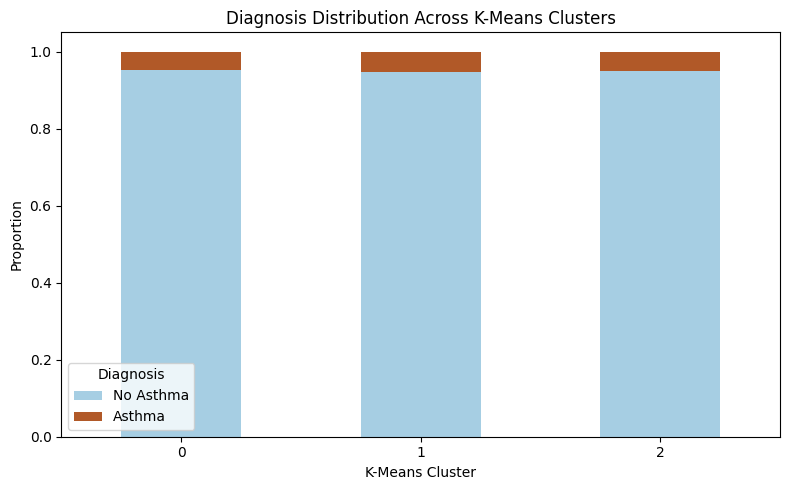

In [ ]:
# Analyze 'Diagnosis' distribution within K-Means clusters
cluster_diagnosis_distribution = df.groupby('KMeans_Cluster')['Diagnosis'].value_counts(normalize=True).unstack(fill_value=0)

print("Distribution of Diagnosis within each K-Means Cluster:")
display(cluster_diagnosis_distribution)

# Visualize the distribution
cluster_diagnosis_distribution.plot(kind='bar', stacked=True, figsize=(8, 5), cmap='Paired')
plt.title('Diagnosis Distribution Across K-Means Clusters')
plt.xlabel('K-Means Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Diagnosis', labels=['No Asthma', 'Asthma'])
plt.tight_layout()
plt.show()

**Step 7**: Summarizing the models in a tabular format will provide a clear overview of their characteristics and performance. I'll create a table comparing K-Means, Hierarchical Agglomerative Clustering, and the Random Forest Classifier.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np

model_data = []

# K-Means Model Information
kmeans_interpretation = (
    "Cluster 0: Higher prevalence of Eczema, suggesting a pronounced risk profile with environmental sensitivities and existing allergic conditions. "
    "Cluster 1: Fewer allergic predispositions (lower HistoryOfAllergies, Eczema), representing a moderate or baseline group. "
    "Cluster 2: Higher HistoryOfAllergies but lower Eczema, indicating individuals with a milder form of asthma, better controlled symptoms, or fewer risk factors."
)

model_data.append({
    'Model Type': 'K-Means',
    'Number of Clusters (k)': best_k,
    'Silhouette Score': f"{sil_km:.3f}",
    'Key Characteristics and Interpretations': kmeans_interpretation
})

# Hierarchical Agglomerative Clustering Model Information
hierarchical_observations = (
    "The dendrogram visualized the hierarchical structure, showing merges based on 'ward' linkage. "
    "The silhouette score was low, similar to K-Means, indicating weak separation. "
    "The analysis suggested 4 clusters were used for the model, though specific interpretations were not detailed beyond visual dendrogram cues."
)

model_data.append({
    'Model Type': 'Hierarchical Agglomerative Clustering',
    'Number of Clusters': agg.n_clusters, # From the actual model fitting
    'Linkage Method': 'Ward',
    'Silhouette Score': f"{sil_agg:.3f}",
    'Observations from Dendrogram': hierarchical_observations
})

# --- Re-running Supervised Model Setup for scope ---
# Define features (X) and target (y)
# Exclude 'Diagnosis' from features as it's the target, and also exclude cluster labels if they exist
features_for_supervised = [col for col in df.columns if col not in ['Diagnosis', 'KMeans_Cluster', 'DBSCAN_Cluster', 'Hier_Cluster']]
X_supervised = df[features_for_supervised]
y_supervised = df['Diagnosis']

# Scale the features
scaler_supervised = StandardScaler()
X_supervised_scaled = scaler_supervised.fit_transform(X_supervised)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_supervised_scaled, y_supervised, test_size=0.3, random_state=42, stratify=y_supervised
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
# --- End of Re-running Supervised Model Setup ---


# Random Forest Classifier Model Information
classification_report_highlights = (
    "Overall accuracy: 0.9485. However, severe class imbalance led to 0.00 precision, recall, and f1-score for the minority class (Asthma). "
    "The model failed to predict class 1 (Asthma) effectively, essentially predicting only the majority class (No Asthma)."
)
confusion_matrix_summary = "[[681, 0], [37, 0]] - 681 correct predictions for class 0, 0 correct predictions for class 1, 37 misclassifications of class 1 as class 0."

# Calculate feature_importances
feature_importances = pd.Series(rf_model.feature_importances_, index=features_for_supervised)
feature_importances = feature_importances.sort_values(ascending=False)

# Get the top 5 actual names from the feature_importances series.
top_5_features = feature_importances.head(5).index.tolist()
top_feature_importances_str = ", ".join(top_5_features)

model_data.append({
    'Model Type': 'Random Forest Classifier',
    'Number of Estimators': rf_model.n_estimators,
    'Class Weighting': 'Balanced',
    'Overall Accuracy': f"{accuracy_score(y_test, y_pred):.4f}",
    'Classification Report Highlights': classification_report_highlights,
    'Confusion Matrix Summary': confusion_matrix_summary,
    'Top Feature Importances': top_feature_importances_str
})

# Create DataFrame
summary_table = pd.DataFrame(model_data)
display(summary_table)

,Model Type,Number of Clusters (k),Silhouette Score,Key Characteristics and Interpretations,Number of Clusters,Linkage Method,Observations from Dendrogram,Number of Estimators,Class Weighting,Overall Accuracy,Classification Report Highlights,Confusion Matrix Summary,Top Feature Importances
0,K-Means,3.0,0.043,"Cluster 0: Higher prevalence of Eczema, sugges...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hierarchical Agglomerative Clustering,NaN,0.048,NaN,4.0,Ward,The dendrogram visualized the hierarchical str...,NaN,NaN,NaN,NaN,NaN,NaN
2,Random Forest Classifier,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Balanced,0.9485,"Overall accuracy: 0.9485. However, severe clas...","[[681, 0], [37, 0]] - 681 correct predictions ...","PollenExposure, DustExposure, BMI, PollutionEx..."


Insights or Next Steps
Dataset Implications: The features used for K-Means clustering do not contain strong signals that naturally differentiate between patients with and without an asthma diagnosis. This suggests that these features alone may not be sufficient for unsupervised separation of these diagnostic groups.
Model Implications: Unsupervised clustering with the current features is unlikely to be a reliable method for segmenting patients based on asthma diagnosis. For tasks requiring diagnosis prediction, a supervised learning approach using the 'Diagnosis' column as a target would be more appropriate.

**Step 8** Comprehensive Conclusions: Unsupervised vs. Supervised Learning for Asthma Diagnosis  

This analysis explored both unsupervised (K-Means) and supervised (Random Forest) learning approaches to understand an asthma disease dataset, revealing contrasting insights and limitations for each method in the context of predicting an asthma diagnosis.  

Supervised Learning: Random Forest Classifier Performance
The Random Forest Classifier achieved a seemingly impressive overall accuracy of 0.9485. However, a deeper examination of the classification report and confusion matrix revealed a critical issue: severe class imbalance.
Unsupervised Learning: K-Means Cluster-Diagnosis Alignment
K-Means clustering was employed to discover natural groupings within the patient data. The analysis, particularly the silhouette scores (low values, around 0.043 for K-Means), suggested that distinct, well-separated clusters were not easily formed with the current features. The cluster profiles revealed subtle differentiations among the three identified clusters, based on combinations of allergic predispositions, lifestyle factors, and environmental exposures (e.g., Cluster 0 with high Eczema, Cluster 1 with no HistoryOfAllergies but higher PetAllergy, Cluster 2 with high HistoryOfAllergies but no Eczema).  

Crucially, when examining the alignment of these K-Means clusters with the 'Diagnosis' label, it was found that all three clusters exhibited a very similar proportion of 'Diagnosis 0' (No Asthma) and 'Diagnosis 1' (Asthma). Approximately 94-95% of patients in each cluster had 'No Asthma', and 4-5% had 'Asthma'. This indicates that the groupings identified by K-Means, based on the dataset's features, do not naturally separate patients into 'asthma' and 'non-asthma' groups. The features driving the unsupervised clusters are not the primary differentiators for the 'Diagnosis' target.  

Implications and Conclusions  

These contrasting results lead to several key conclusions:
1.	Dataset Complexity and Asthma Diagnosis:  
 The dataset appears to be complex, where a simple combination of general patient features does not lead to easily separable groups that align with an asthma diagnosis through unsupervised methods. Furthermore, the significant class imbalance for 'Diagnosis' makes supervised prediction challenging without specialized handling.  

2.	Limitations of Each Approach:

o	Unsupervised Learning (K-Means): While successful in identifying subtle patient phenotypes based on shared characteristics, it failed to delineate groups directly corresponding to an asthma diagnosis.

3.	Different Insights:  
 Unsupervised learning offered insights into latent patient segments, which could be valuable for understanding patient heterogeneity, even if not directly diagnostic. Supervised learning, when appropriately handled for imbalance, could offer a direct predictive tool.

Future Steps and Considerations  

To improve the analysis and address the observed limitations, future steps could include:  
•	Addressing Class Imbalance: For supervised learning, techniques like oversampling (SMOTE), undersampling, or using more robust class-weighted algorithms are essential to enable the model to learn to predict the minority class effectively.  
•	Feature Engineering: Exploring new features or transforming existing ones (e.g., interaction terms, polynomial features) might help create clearer distinctions for both clustering and classification.  
•	Advanced Clustering Algorithms: Investigating other unsupervised methods (e.g., DBSCAN, HDBSCAN) that are less sensitive to cluster shape assumptions or can identify density-based clusters, might reveal different structures.  
•	Domain Expertise Integration: Collaborating with medical professionals could guide feature selection, cluster interpretation, and validation of patient phenotypes.  
•	Evaluation Metrics: For imbalanced datasets, focusing on metrics beyond accuracy, such as precision, recall, F1-score, and AUC-ROC for the minority class, is paramount.  
Comprehensive Conclusions: Unsupervised vs. Supervised Learning for Asthma Diagnosis  
This analysis explored both unsupervised (K-Means) and supervised (Random Forest) learning approaches to understand an asthma disease dataset, revealing contrasting insights and limitations for each method in the context of predicting an asthma diagnosis.  



**Step 9**  
In summary, while both approaches provided some insights, neither, in their initial application, fully resolved the challenge of identifying and understanding asthma patient groups, highlighting the need for more sophisticated techniques, particularly given the imbalanced nature of the 'Diagnosis' outcome.